## Config

In [85]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


In [86]:
plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = Path() / "data" / "clean"

def load_file(file, sep=',', skiprows=0, index_col=None) -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / file, 
        sep=sep,
        low_memory=False,
        encoding='utf-8',
        skiprows=skiprows,
        na_values=['..', 'NA', 'N/A', ''],
        index_col=index_col
    ).dropna(how='all')

    show_info(df)
    return df

def show_info(df):
    print("SHAPE:")
    print(df.shape)

    print("\n--------")
    print("INFO:")
    df.info()

    print("\n--------")
    print("SAMPLE:")
    display(df.head())

    print("\n--------")
    print("MISSING VALUES:")
    missing = pd.DataFrame({
        'count': df.isnull().sum(),
        'percentage': (df.isnull().mean() * 100).round(2)
    })
    display(missing[missing['count'] > 0])  # only shows columns WITH missing values

    print("\n--------")
    print("UNIQUE VALUES:")
    print(df.nunique())

    print("\n--------")
    print("STATISTICAL SUMMARY:")
    display(df.describe())


## Load data

In [87]:
df = load_file("master_2017.csv", index_col="country")

SHAPE:
(149, 12)

--------
INFO:
<class 'pandas.DataFrame'>
Index: 149 entries, Afghanistan to Zimbabwe
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   population             149 non-null    float64
 1   poultry_supply_capita  149 non-null    float64
 2   poultry_import         149 non-null    float64
 3   poultry_production     149 non-null    float64
 4   GDP                    149 non-null    float64
 5   stability              149 non-null    float64
 6   urban                  149 non-null    float64
 7   animal_protein_ratio   149 non-null    float64
 8   poultry_protein_ratio  149 non-null    float64
 9   production_per_capita  149 non-null    float64
 10  poultry_gap            149 non-null    float64
 11  import_dependency      149 non-null    float64
dtypes: float64(12)
memory usage: 15.1+ KB

--------
SAMPLE:


,population,poultry_supply_capita,poultry_import,poultry_production,GDP,stability,urban,animal_protein_ratio,poultry_protein_ratio,production_per_capita,poultry_gap,import_dependency
country,,,,,,,,,,,,
Afghanistan,35688935.0,1.79,28937000.0,27637840.0,2335.795862,-2.613931,24.835282,18.000918,6.887755,0.774409,1.015591,45.214062
Albania,2898242.0,11.47,17515470.0,12912000.0,14110.683242,0.163830,55.980276,55.354994,8.136646,4.455115,7.014885,53.077182
Algeria,41689299.0,6.86,400.0,364252170.0,13493.560749,-0.929505,71.322791,31.355560,10.947884,8.737306,-1.877306,0.000140
Angola,30234839.0,10.50,265888300.0,40460720.0,8006.836615,-0.537214,65.085053,33.642034,26.741573,1.338215,9.161785,83.612673
Antigua and Barbuda,90468.0,69.28,6143690.0,23480.0,21422.002158,0.614623,24.850026,68.266611,48.357384,0.259539,69.020461,87.767000



--------
MISSING VALUES:


,count,percentage



--------
UNIQUE VALUES:
population               149
poultry_supply_capita    146
poultry_import           149
poultry_production       149
GDP                      149
stability                149
urban                    149
animal_protein_ratio     149
poultry_protein_ratio    149
production_per_capita    149
poultry_gap              149
import_dependency        149
dtype: int64

--------
STATISTICAL SUMMARY:


,population,poultry_supply_capita,poultry_import,poultry_production,GDP,stability,urban,animal_protein_ratio,poultry_protein_ratio,production_per_capita,poultry_gap,import_dependency
count,1.490000e+02,149.000000,1.490000e+02,1.490000e+02,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,4.781040e+07,20.368389,6.511917e+07,7.147507e+08,20209.440621,-0.105231,58.744319,44.742236,21.880913,16.220160,4.148230,31.068718
std,1.647757e+08,15.197898,1.308253e+08,2.268006e+09,19242.657554,0.859713,21.304031,15.506058,12.931268,15.965379,13.051673,33.740108
min,9.046800e+04,0.620000,3.000000e+01,2.348000e+04,990.545051,-2.613931,13.524964,7.910801,1.698571,0.070868,-43.944155,0.000001
25%,2.914963e+06,7.220000,2.752280e+06,1.530000e+07,5353.066088,-0.653347,42.448601,32.312704,11.136537,2.208664,0.005816,3.308647
50%,9.968510e+06,18.800000,1.330698e+07,9.094400e+07,13718.937867,-0.056395,60.240269,46.538187,19.402776,12.019215,1.999012,17.692390
75%,3.544639e+07,28.370000,5.291815e+07,4.360400e+08,28681.681559,0.629429,74.539560,56.570991,32.439199,26.026625,7.548653,58.192876
max,1.412355e+09,73.010000,7.884518e+08,1.914057e+10,114985.842236,1.271542,100.000000,74.931166,53.755102,66.473489,71.068370,135.127064


## Standardise

In [88]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(
    X_scaled,
    index=df.index,
    columns=df.columns
)

X_scaled.describe().round(2)

,population,poultry_supply_capita,poultry_import,poultry_production,GDP,stability,urban,animal_protein_ratio,poultry_protein_ratio,production_per_capita,poultry_gap,import_dependency
count,149.00,149.00,149.00,149.00,149.00,149.00,149.00,149.00,149.00,149.00,149.00,149.00
mean,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.29,-1.30,-0.50,-0.32,-1.00,-2.93,-2.13,-2.38,-1.57,-1.01,-3.70,-0.92
25%,-0.27,-0.87,-0.48,-0.31,-0.77,-0.64,-0.77,-0.80,-0.83,-0.88,-0.32,-0.83
50%,-0.23,-0.10,-0.40,-0.28,-0.34,0.06,0.07,0.12,-0.19,-0.26,-0.17,-0.40
75%,-0.08,0.53,-0.09,-0.12,0.44,0.86,0.74,0.77,0.82,0.62,0.26,0.81
max,8.31,3.48,5.55,8.15,4.94,1.61,1.94,1.95,2.47,3.16,5.14,3.09


### Boxplot

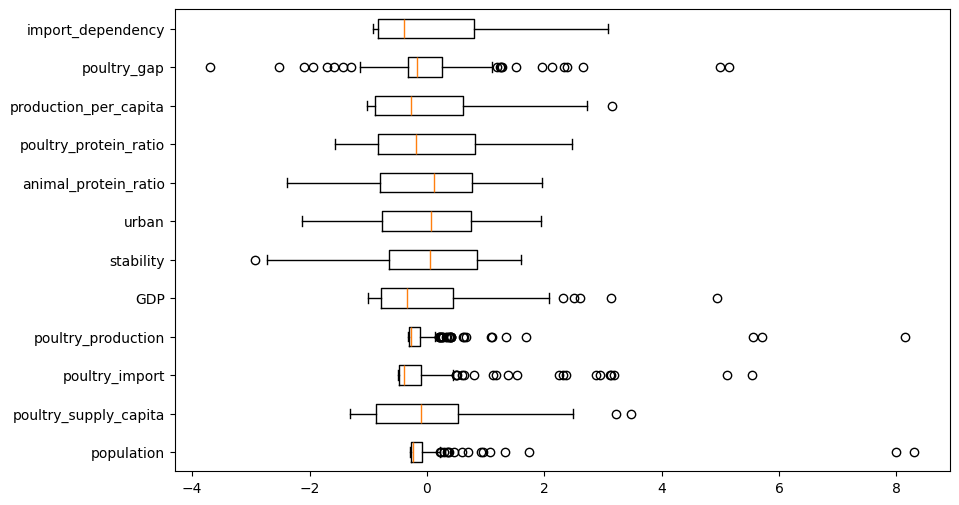

In [89]:
plt.boxplot(
    X_scaled,
    tick_labels=X_scaled.columns,
    orientation='horizontal'
)

plt.show()

### Heatmap

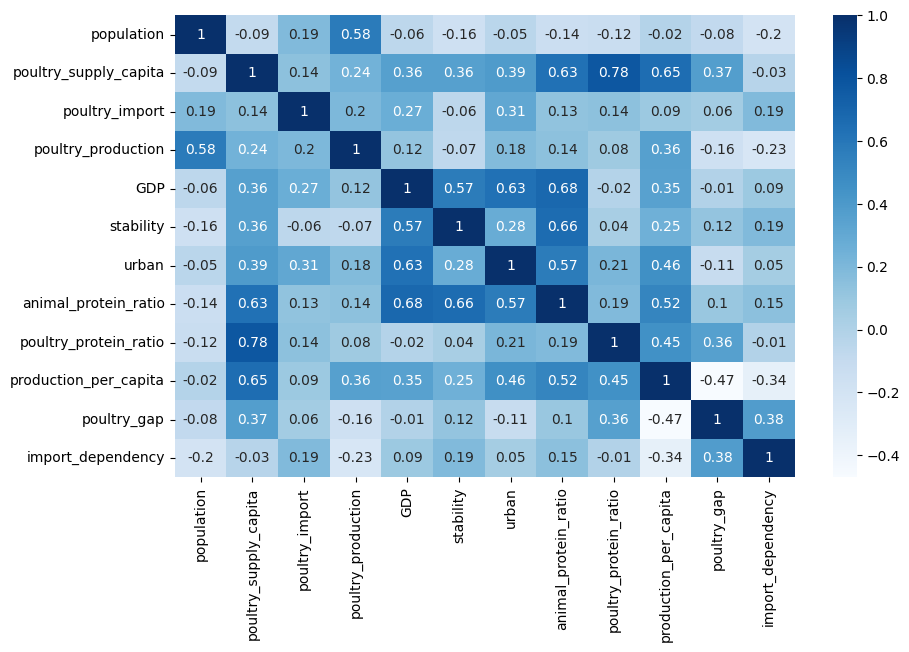

In [90]:
corr = X_scaled.corr()

sns.heatmap(
    corr.round(2),
    annot=True,
    cmap='Blues'
)
plt.show()

## PCA

In [91]:
pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_ * 100
cumulative = explained.cumsum()

pd.DataFrame({
    'eigenvalue': pca.explained_variance_.round(2),
    'variance_%': explained.round(2),
    'cumulative_%': cumulative.round(2)
}, index=[f'PC{i+1}' for i in range(len(explained))])

,eigenvalue,variance_%,cumulative_%
PC1,3.82,31.63,31.63
PC2,2.15,17.81,49.44
PC3,1.67,13.80,63.25
PC4,1.47,12.20,75.44
PC5,1.00,8.24,83.68
PC6,0.57,4.73,88.41
PC7,0.49,4.05,92.47
PC8,0.35,2.91,95.38
PC9,0.25,2.10,97.48
PC10,0.23,1.89,99.36


### Eigenvectors (== loadings if data is scaled)

In [92]:
pd.DataFrame(
    pca.components_.round(2),
    columns=df.columns,
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

,population,poultry_supply_capita,poultry_import,poultry_production,GDP,stability,urban,animal_protein_ratio,poultry_protein_ratio,production_per_capita,poultry_gap,import_dependency
PC1,-0.05,0.43,0.15,0.14,0.38,0.31,0.37,0.44,0.26,0.37,0.04,0.02
PC2,0.42,-0.05,0.07,0.48,-0.05,-0.24,0.06,-0.11,-0.06,0.32,-0.45,-0.45
PC3,0.07,0.39,0.05,0.12,-0.37,-0.29,-0.19,-0.18,0.61,0.05,0.40,-0.07
PC4,0.47,-0.09,0.55,0.31,0.15,-0.06,0.10,-0.01,-0.13,-0.33,0.29,0.37
PC5,-0.39,-0.10,0.54,-0.28,-0.01,-0.43,0.33,-0.18,0.15,0.13,-0.28,0.12
PC6,-0.04,-0.00,-0.09,0.27,-0.34,0.09,-0.23,0.09,0.05,0.29,-0.36,0.72
PC7,-0.05,-0.04,-0.56,0.25,0.01,-0.41,0.61,-0.00,-0.01,-0.14,0.12,0.21
PC8,0.57,-0.09,-0.12,-0.49,-0.15,0.30,0.35,-0.23,0.30,0.04,-0.16,0.12
PC9,0.25,0.12,0.04,-0.36,-0.36,-0.36,-0.00,0.67,-0.28,0.07,0.05,-0.04
PC10,0.24,0.12,-0.20,-0.25,0.65,-0.42,-0.37,-0.08,0.06,0.17,-0.07,0.22


### Visualisation

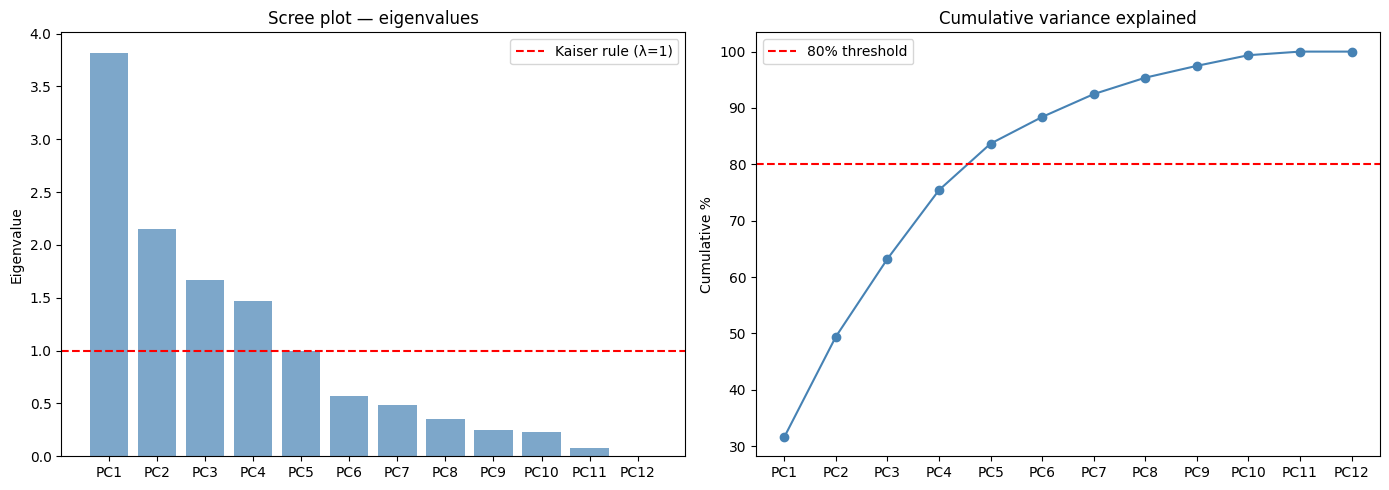

In [93]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
axes = [f'PC{i+1}' for i in range(len(explained))]

# scree plot (eigenvalues)
ax1.bar(axes, pca.explained_variance_, color='steelblue', alpha=0.7)
ax1.axhline(y=1, color='red', linestyle='--', label='Kaiser rule (λ=1)')
# draws a horizontal red dashed line at y=1 -> the Kaiser threshold

ax1.set_title('Scree plot — eigenvalues')
ax1.set_ylabel('Eigenvalue')
ax1.legend()

# cumulative variance
ax2.plot(axes, cumulative, marker='o', color='steelblue')
ax2.axhline(y=80, color='red', linestyle='--', label='80% threshold')

ax2.set_title('Cumulative variance explained')
ax2.set_ylabel('Cumulative %')
ax2.legend()

plt.tight_layout()
plt.show()

## Transform into new coordinates
> Only keep PC1 - PC5

In [94]:
pca5 = PCA(n_components=5)

coordinates = pca5.fit_transform(X_scaled)

df_coords = pd.DataFrame(
    coordinates,
    index=df.index,
    columns=[f'PC{i+1}' for i in range(5)]
)

print(df_coords.shape)
df_coords.head()

(149, 5)


,PC1,PC2,PC3,PC4,PC5
country,,,,,
Afghanistan,-3.871817,0.370889,0.381926,0.281909,0.960203
Albania,-0.631401,-0.973403,-1.015952,0.235610,-0.489166
Algeria,-1.493891,0.819137,-0.608763,-0.394302,0.476684
Angola,-0.892207,-1.007593,0.459303,1.676333,1.497545
Antigua and Barbuda,2.021239,-4.373071,4.038176,1.123890,-2.578178


## NI scatter plot (nuage des individus)

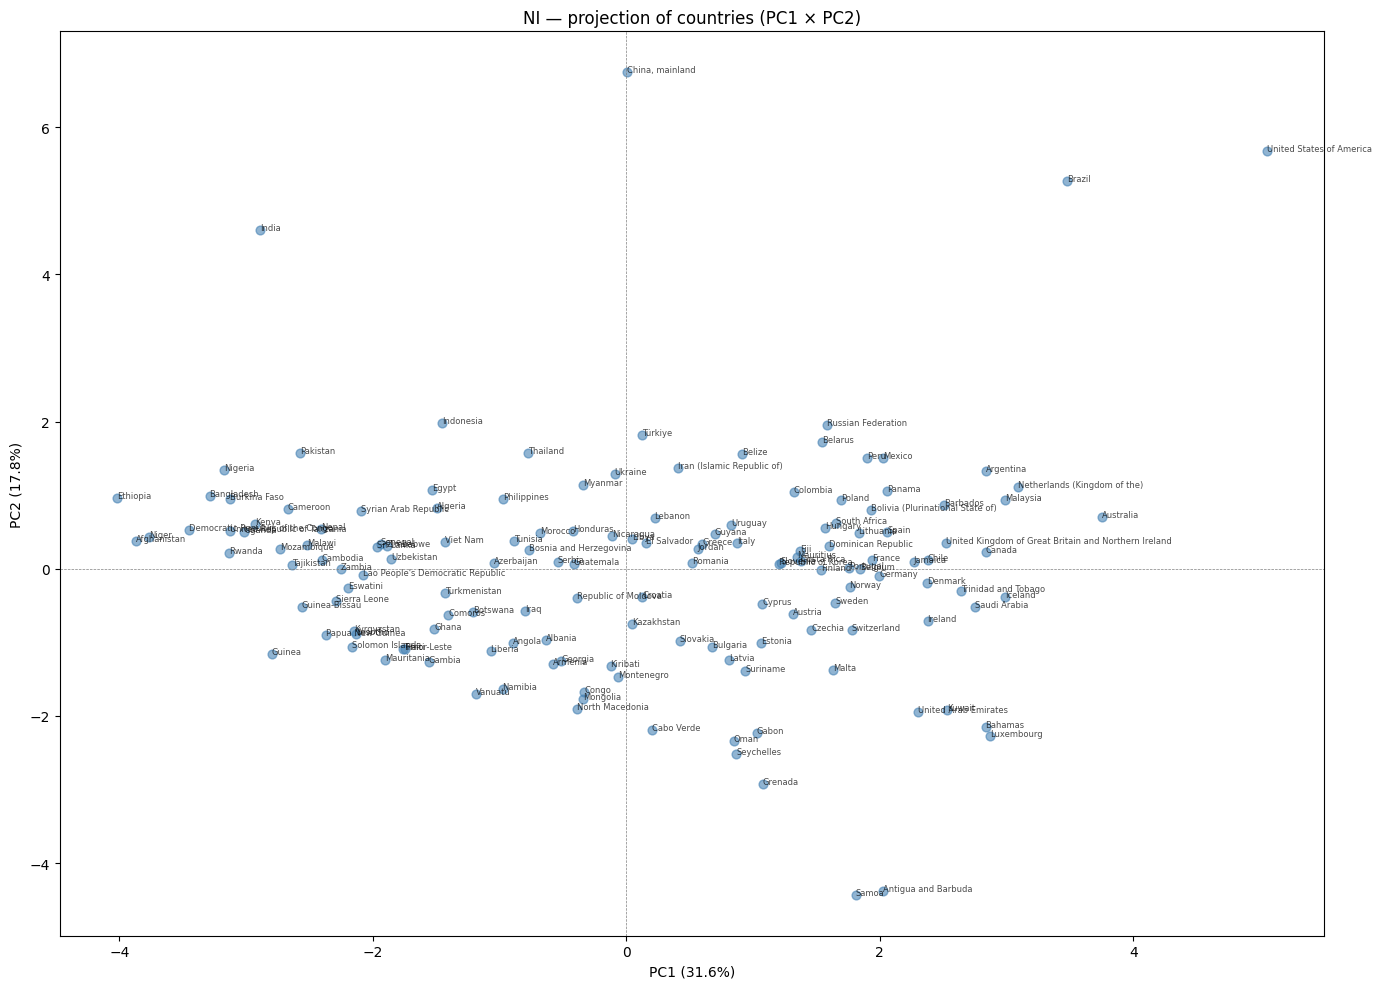

In [95]:
fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(
    df_coords['PC1'], 
    df_coords['PC2'], 
    color='steelblue', 
    alpha=0.6, 
    s=40
)

for country in df_coords.index:
    ax.annotate(
        country, 
        xy=(df_coords.loc[country, 'PC1'], 
            df_coords.loc[country, 'PC2']),
        fontsize=6, alpha=0.7
    )

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
ax.set_title('NI — projection of countries (PC1 × PC2)')

plt.tight_layout()
plt.show()

## NK Correlation Circle

### PC1 vs. PC2

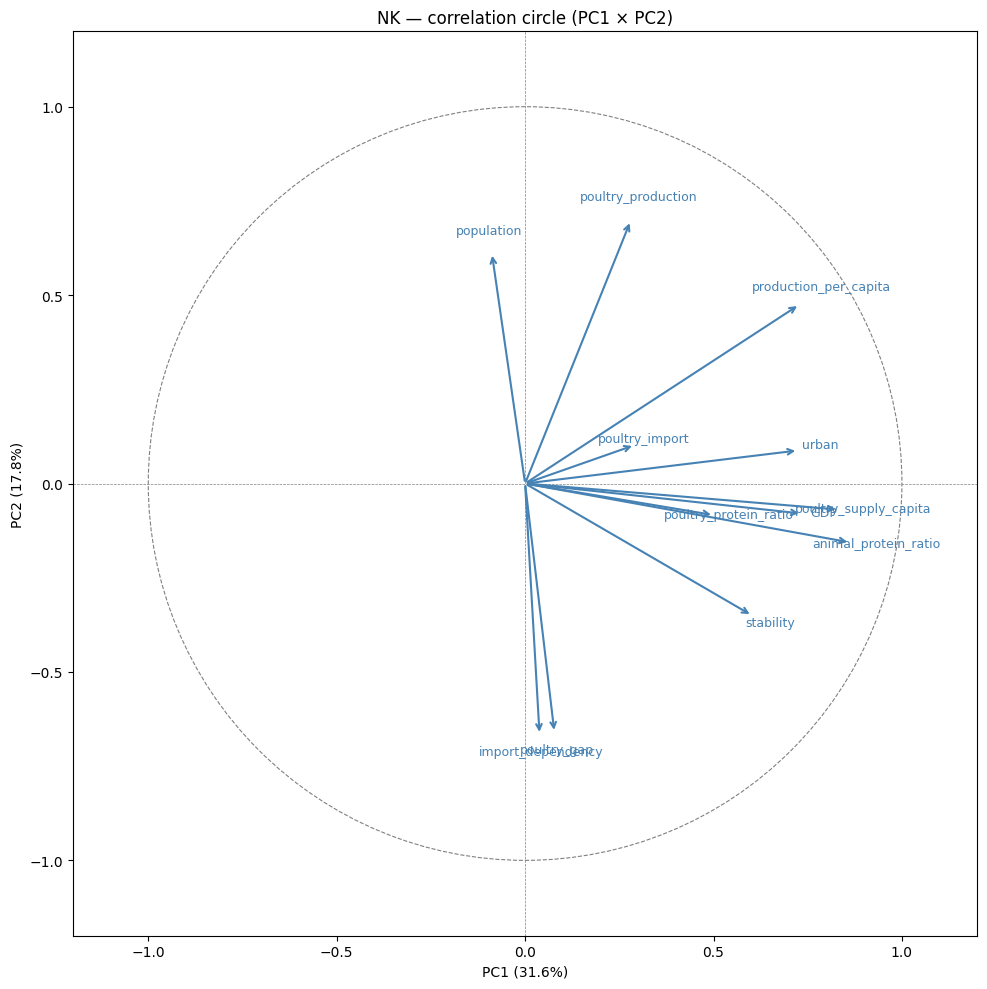

In [96]:
loadings = pca5.components_.T * np.sqrt(pca5.explained_variance_)
# T -> pivot the table

loadings_df = pd.DataFrame(
    loadings,
    index=df.columns,
    columns=[f'PC{i+1}' for i in range(5)]
)

fig, ax = plt.subplots(figsize=(10, 10))

circle = plt.Circle((0, 0), 1, fill=False, color='grey', linestyle='--', linewidth=0.8)
ax.add_patch(circle)

for var in loadings_df.index:
    x = loadings_df.loc[var, 'PC1']
    y = loadings_df.loc[var, 'PC2']
    
    ax.annotate('', xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
    
    ax.text(x * 1.08, y * 1.08, var, fontsize=9, ha='center', color='steelblue')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
ax.set_title('NK — correlation circle (PC1 × PC2)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### PC1 vs. PC3

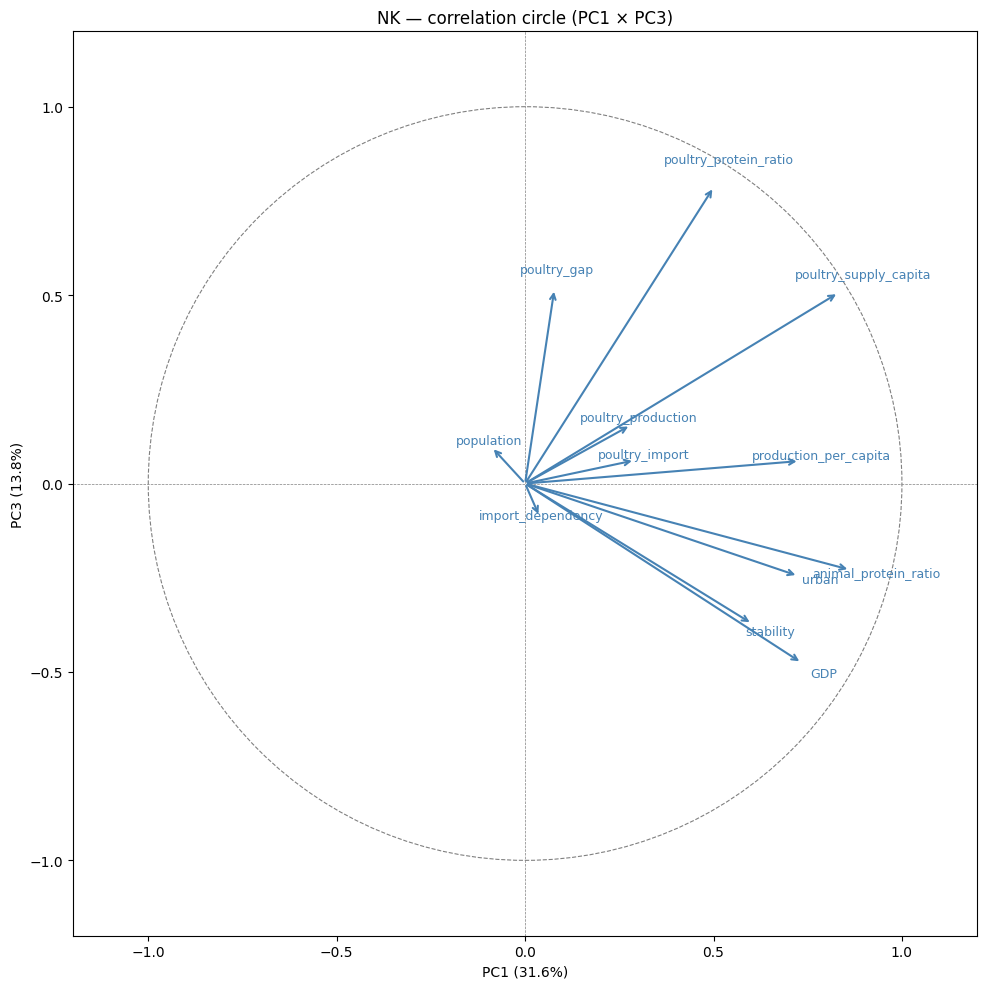

In [97]:
fig, ax = plt.subplots(figsize=(10, 10))

circle = plt.Circle((0, 0), 1, fill=False, color='grey', linestyle='--', linewidth=0.8)
ax.add_patch(circle)

for var in loadings_df.index:
    x = loadings_df.loc[var, 'PC1']
    y = loadings_df.loc[var, 'PC3']
    
    ax.annotate('', xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
    
    ax.text(x * 1.08, y * 1.08, var, fontsize=9, ha='center', color='steelblue')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC3 ({explained[2]:.1f}%)')
ax.set_title('NK — correlation circle (PC1 × PC3)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### PC2 vs. PC3

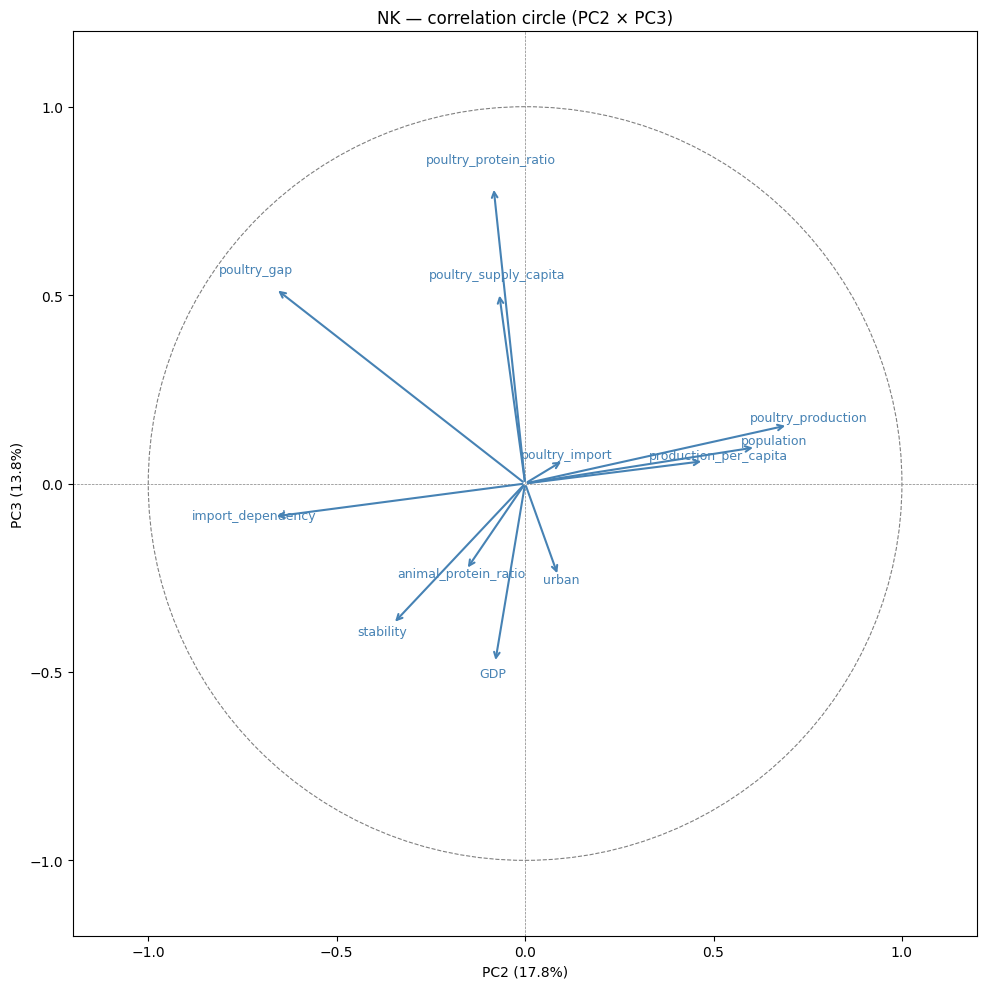

In [98]:
fig, ax = plt.subplots(figsize=(10, 10))

circle = plt.Circle((0, 0), 1, fill=False, color='grey', linestyle='--', linewidth=0.8)
ax.add_patch(circle)

for var in loadings_df.index:
    x = loadings_df.loc[var, 'PC2']
    y = loadings_df.loc[var, 'PC3']
    
    ax.annotate('', xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
    
    ax.text(x * 1.08, y * 1.08, var, fontsize=9, ha='center', color='steelblue')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

ax.set_xlabel(f'PC2 ({explained[1]:.1f}%)')
ax.set_ylabel(f'PC3 ({explained[2]:.1f}%)')
ax.set_title('NK — correlation circle (PC2 × PC3)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Summary of PC axis

#### PC 1 = development / wealth axis
- high PC1 = rich, urbanised, high protein consumption  
- low PC1  = poor, rural, low consumption

#### PC2 = country scale axis
- import_dependency       ↓
- poultry_production      ↑
- population              ↑

#### PC3 = poultry protein axis
- poultry_protein_ratio   ↑

## CAH (Classification Ascendante Hiérarchique)

In [99]:
Z = linkage(df_coords, method='ward')
# Z -> conventional name
# ward = at each step, merges the two groups that increase, within-cluster inertia the least

print(f"Z shape: {Z.shape}")

Z shape: (148, 4)


### Dendrogram

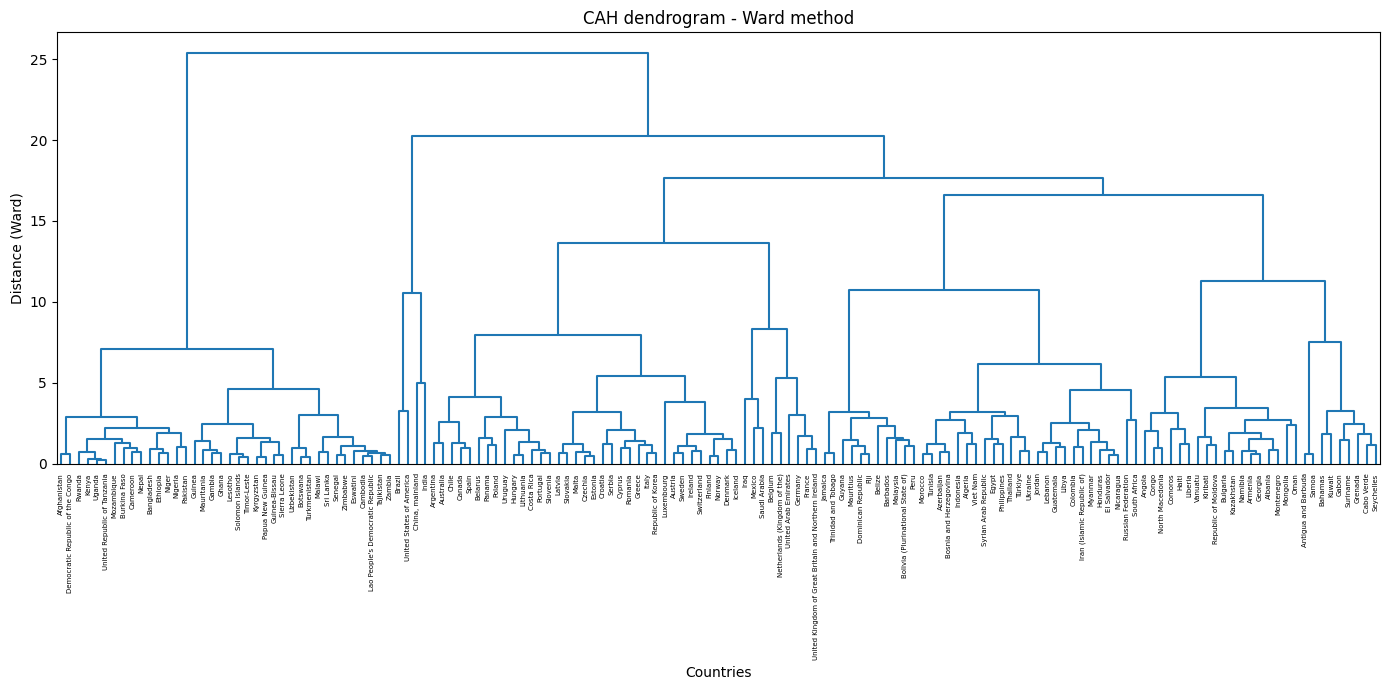

In [100]:
fig, ax = plt.subplots(figsize=(14, 7))

dendrogram(
    Z,
    labels=df_coords.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=5,
    color_threshold=0,
    ax=ax
)

ax.set_title('CAH dendrogram - Ward method')
ax.set_xlabel('Countries')
ax.set_ylabel('Distance (Ward)')

plt.tight_layout()
plt.show()

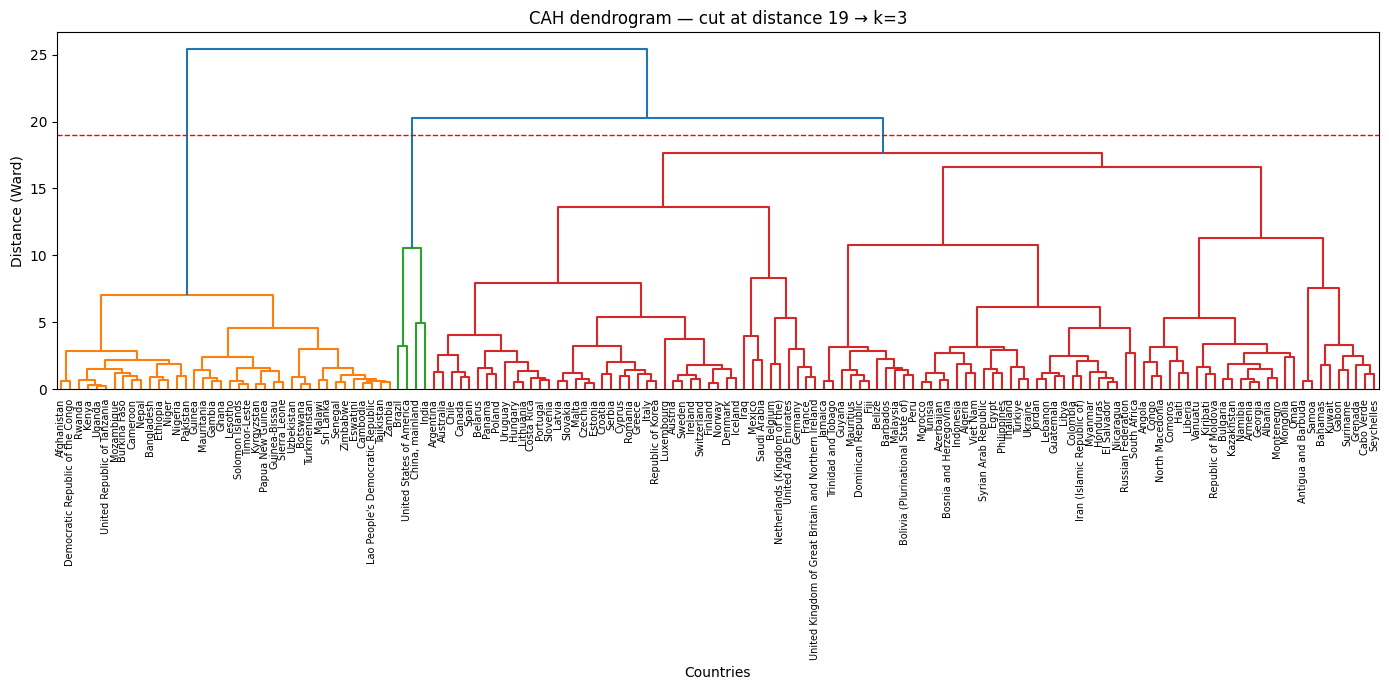

In [101]:
fig, ax = plt.subplots(figsize=(14, 7))

dendrogram(
    Z,
    labels=df_coords.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=19,
    # colours the clusters differently below the cut threshold
    ax=ax
)

ax.axhline(y=19, color='red', linestyle='--', linewidth=1)

ax.set_title('CAH dendrogram — cut at distance 19 → k=3')
ax.set_xlabel('Countries')
ax.set_ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

## KMeans

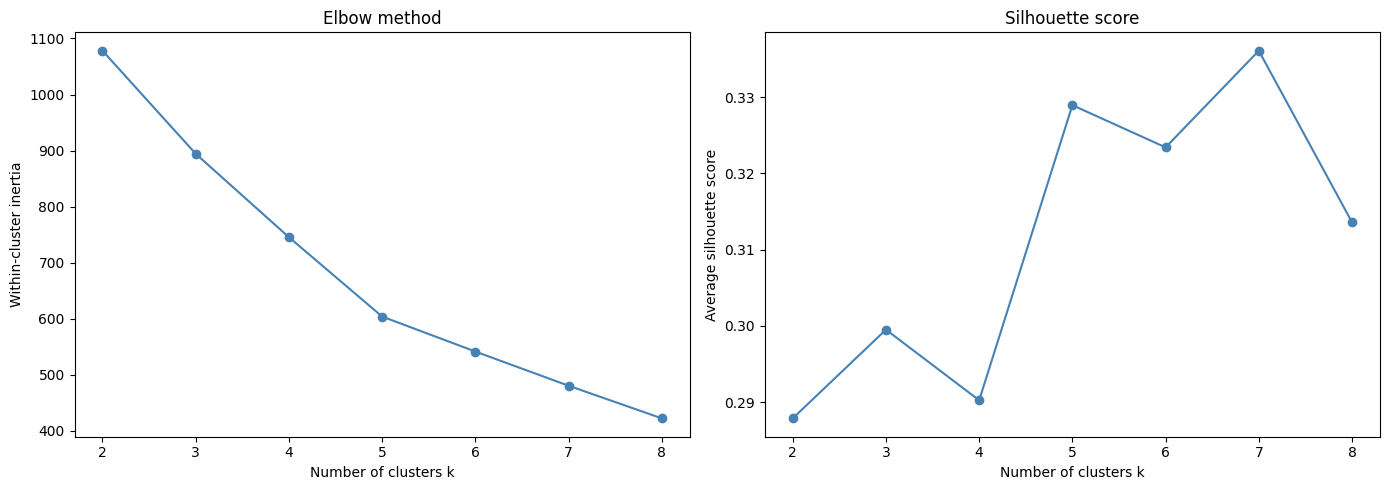

In [102]:
inertias = []
silhouettes = []
K = range(2, 9)
# tests k from 2 to 8 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_coords)
    # n_init=10 means run this 10 times from 10 different starting points and keep the best results
    
    inertias.append(km.inertia_)
    # inertia = total within-cluster spread/distance to the centroid (lower = tighter clusters)
    
    silhouettes.append(silhouette_score(df_coords, labels))
    # silhouette = how well each country fits its cluster (higher = better)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K, inertias, marker='o', color='steelblue')
ax1.set_title('Elbow method')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Within-cluster inertia')

ax2.plot(K, silhouettes, marker='o', color='steelblue')
ax2.set_title('Silhouette score')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Average silhouette score')

plt.tight_layout()
plt.show()

#### Results: k=5
- CAH dendrogram  → k=3  (but red group was very large...)
- Elbow method    → k=5  (curve flattens here)
- Silhouette      → k=7  (very close to k=5)

### KMeans with k=5

In [103]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)

cluster_labels = km.fit_predict(df_coords)
# returns an array of cluster numbers/labels (0,1,2,3,4) for each country

df_coords['cluster'] = cluster_labels

print(df_coords['cluster'].value_counts().sort_index())

cluster
0    37
1    61
2    29
3    18
4     4
Name: count, dtype: int64


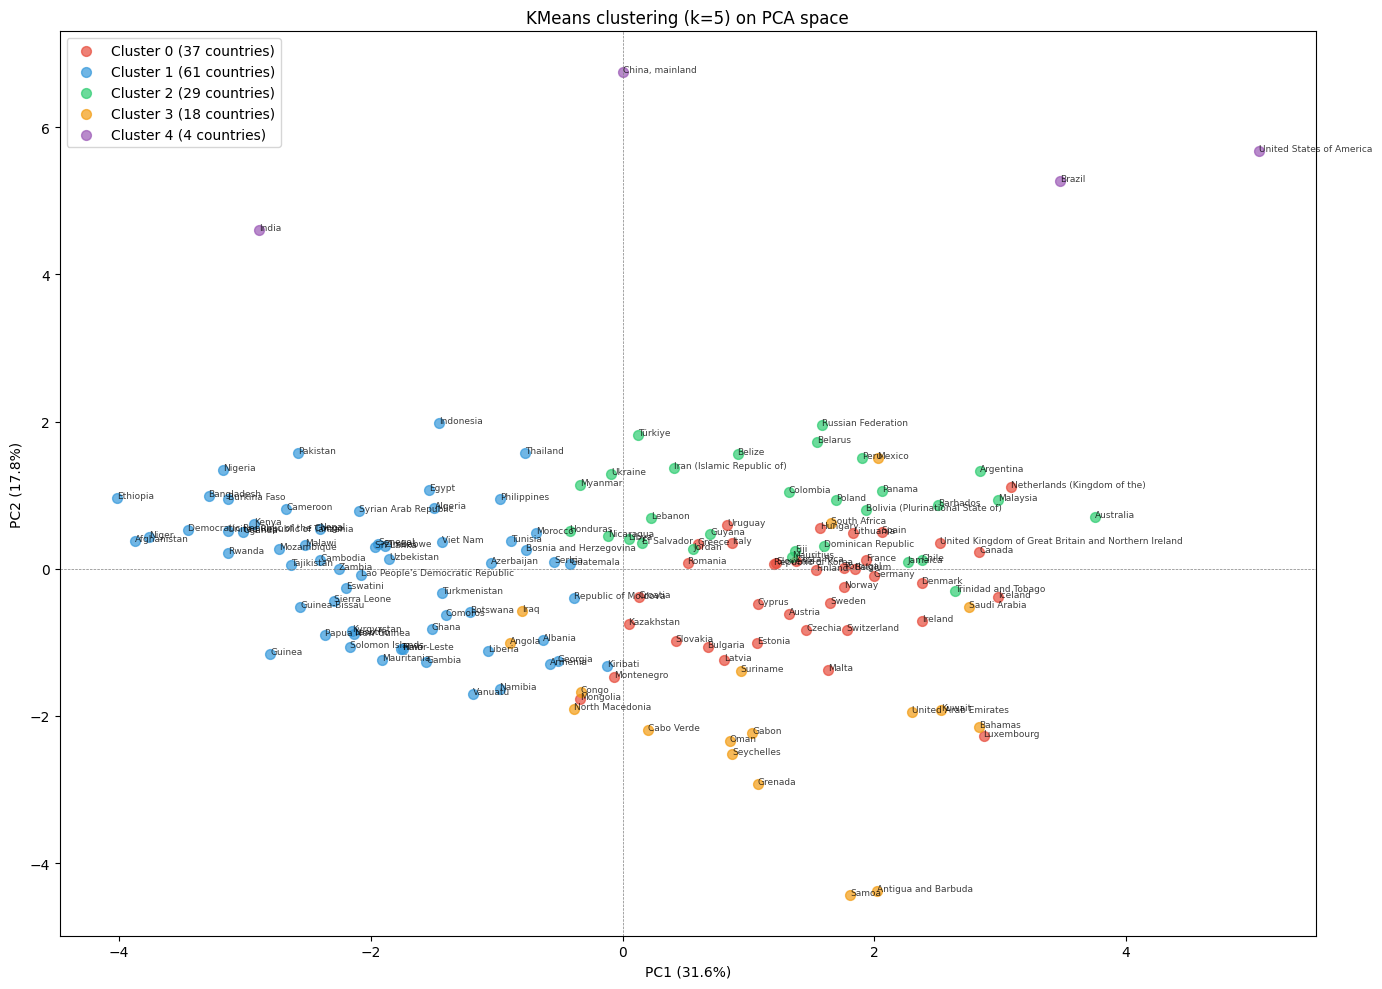

In [104]:
fig, ax = plt.subplots(figsize=(14, 10))

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

for cluster in range(5):
    mask = df_coords['cluster'] == cluster
    
    ax.scatter(
        df_coords.loc[mask, 'PC1'],
        df_coords.loc[mask, 'PC2'],
        c=colors[cluster],
        label=f'Cluster {cluster} ({mask.sum()} countries)',
        alpha=0.7,
        s=50
    )

for country in df_coords.index:
    ax.annotate(
        country,
        xy=(df_coords.loc[country, 'PC1'],
            df_coords.loc[country, 'PC2']),
        fontsize=6.5,
        alpha=0.75
    )

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
ax.set_title('KMeans clustering (k=5) on PCA space')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

#### Clusters details on original columns

In [105]:
df['cluster'] = cluster_labels

profile = df.groupby('cluster').mean().round(2)
profile

,population,poultry_supply_capita,poultry_import,poultry_production,GDP,stability,urban,animal_protein_ratio,poultry_protein_ratio,production_per_capita,poultry_gap,import_dependency
cluster,,,,,,,,,,,,
0,1.640116e+07,21.07,8.800871e+07,3.479255e+08,42272.30,0.72,74.50,60.57,14.93,20.78,0.29,37.17
1,3.539636e+07,7.88,2.234073e+07,2.207080e+08,6513.22,-0.56,42.50,31.37,14.96,5.06,2.81,29.04
2,2.544905e+07,34.94,3.030179e+07,8.469348e+08,18221.79,-0.25,67.89,49.26,36.36,36.22,-1.29,5.87
3,1.726588e+07,35.72,2.051715e+08,3.225804e+08,23645.52,0.01,65.29,49.67,36.36,8.46,27.27,72.74
4,8.272301e+08,29.62,1.279525e+08,1.244847e+10,23943.48,-0.32,65.01,47.38,21.60,34.07,-4.45,0.73


In [106]:
test = X_scaled.copy()
test['cluster'] = cluster_labels
test = test.groupby('cluster').mean().round(2)
test

,population,poultry_supply_capita,poultry_import,poultry_production,GDP,stability,urban,animal_protein_ratio,poultry_protein_ratio,production_per_capita,poultry_gap,import_dependency
cluster,,,,,,,,,,,,
0,-0.19,0.05,0.18,-0.16,1.15,0.97,0.74,1.02,-0.54,0.29,-0.30,0.18
1,-0.08,-0.82,-0.33,-0.22,-0.71,-0.53,-0.76,-0.87,-0.54,-0.70,-0.10,-0.06
2,-0.14,0.96,-0.27,0.06,-0.10,-0.17,0.43,0.29,1.12,1.26,-0.42,-0.75
3,-0.19,1.01,1.07,-0.17,0.18,0.13,0.31,0.32,1.12,-0.49,1.78,1.24
4,4.75,0.61,0.48,5.19,0.19,-0.25,0.29,0.17,-0.02,1.12,-0.66,-0.90


#### Listing countries in clusters

In [107]:
for cluster_num in range(5):
    countries = df[df['cluster'] == cluster_num].index.tolist()
    
    print(f"\nCluster {cluster_num} ({len(countries)} countries):")
    print(", ".join(sorted(countries)))


Cluster 0 (37 countries):
Austria, Belgium, Bulgaria, Canada, Costa Rica, Croatia, Cyprus, Czechia, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Iceland, Ireland, Italy, Kazakhstan, Latvia, Lithuania, Luxembourg, Malta, Mongolia, Montenegro, Netherlands (Kingdom of the), Norway, Portugal, Republic of Korea, Romania, Slovakia, Slovenia, Spain, Sweden, Switzerland, United Kingdom of Great Britain and Northern Ireland, Uruguay

Cluster 1 (61 countries):
Afghanistan, Albania, Algeria, Armenia, Azerbaijan, Bangladesh, Bosnia and Herzegovina, Botswana, Burkina Faso, Cambodia, Cameroon, Comoros, Democratic Republic of the Congo, Egypt, Eswatini, Ethiopia, Gambia, Georgia, Ghana, Guatemala, Guinea, Guinea-Bissau, Haiti, Indonesia, Kenya, Kiribati, Kyrgyzstan, Lao People's Democratic Republic, Lesotho, Liberia, Malawi, Mauritania, Morocco, Mozambique, Namibia, Nepal, Niger, Nigeria, Pakistan, Papua New Guinea, Philippines, Republic of Moldova, Rwanda, Senegal, Serbia, Sierra Le

## Market segmentation

### Summary

In [108]:
cluster_names = {
    0: 'Developed economies',
    1: 'Low-income countries',
    2: 'Middle-income economies',
    3: 'Import-dependent',
    4: 'Poultry giants'
}
recommendation = {
    0: 'Strong potential',
    1: 'Not ready',
    2: 'Self-sufficient',
    3: 'Priority target',
    4: 'Self-sufficient'
}

summary = pd.DataFrame({
    'name': [cluster_names[i] for i in range(5)],
    
    'n_countries': [
        (df['cluster'] == i).sum() for i in range(5)
    ],
    
    'avg_GDP': [
        round(df[df['cluster']==i]['GDP'].mean(), 0) for i in range(5)
    ],
    
    'avg_import_dependency': [
        round(df[df['cluster']==i]['import_dependency'].mean(), 1) 
        for i in range(5)
    ],
    
    'avg_supply_capita': [
        round(df[df['cluster']==i]['poultry_supply_capita'].mean(), 1) 
        for i in range(5)
    ],

    'avg_stability': [
        round(df[df['cluster']==i]['stability'].mean(), 1) 
        for i in range(5)
    ],
    
    'recommendation': [recommendation[i] for i in range(5)]
}, index=range(5))

summary

,name,n_countries,avg_GDP,avg_import_dependency,avg_supply_capita,avg_stability,recommendation
0,Developed economies,37,42272.0,37.2,21.1,0.7,Strong potential
1,Low-income countries,61,6513.0,29.0,7.9,-0.6,Not ready
2,Middle-income economies,29,18222.0,5.9,34.9,-0.3,Self-sufficient
3,Import-dependent,18,23646.0,72.7,35.7,0.0,Priority target
4,Poultry giants,4,23943.0,0.7,29.6,-0.3,Self-sufficient


### Priority target

In [109]:
cluster3 = df[df['cluster'] == 3][[
    'GDP', 
    'urban',
    'stability', 
    'import_dependency',
    'poultry_supply_capita'
]].sort_values('GDP', ascending=False).round(2)

priority = cluster3[
    (cluster3['stability'] > -0.5) &
    (cluster3['GDP'] > 10000) &
    (cluster3['import_dependency'] > 40) &
    (cluster3['urban'] > 50)
]

priority_country = priority.index.tolist()

print(f"{len(priority)} priority countries identified: {priority_country}")
priority.round(1)

7 priority countries identified: ['United Arab Emirates', 'Kuwait', 'Bahamas', 'Oman', 'Suriname', 'North Macedonia', 'Gabon']


,GDP,urban,stability,import_dependency,poultry_supply_capita
country,,,,,
United Arab Emirates,70281.9,84.7,0.7,89.0,26.8
Kuwait,46565.6,100.0,0.0,69.3,45.2
Bahamas,34282.2,82.1,0.8,51.0,51.4
Oman,33619.5,78.3,0.6,106.6,22.3
Suriname,17567.7,66.1,0.2,65.6,31.7
North Macedonia,17161.0,59.7,-0.2,89.4,21.3
Gabon,14796.6,89.0,-0.4,76.6,37.1


#### Summary of countries

In [110]:
print(f"Avg GDP of cluster 3: {cluster3.GDP.mean().round()} $/per")
print(f"Avg Urbanisation of cluster 3: {cluster3.urban.mean().round()} %")
print(f"Avg import-dependency of cluster 3: {cluster3.import_dependency.mean().round()} %")
print(f"Avg supply/cap of cluster 3: {cluster3.poultry_supply_capita.mean().round()} kg/year")

Avg GDP of cluster 3: 23646.0 $/per
Avg Urbanisation of cluster 3: 65.0 %
Avg import-dependency of cluster 3: 73.0 %
Avg supply/cap of cluster 3: 36.0 kg/year


#### Graph 2D

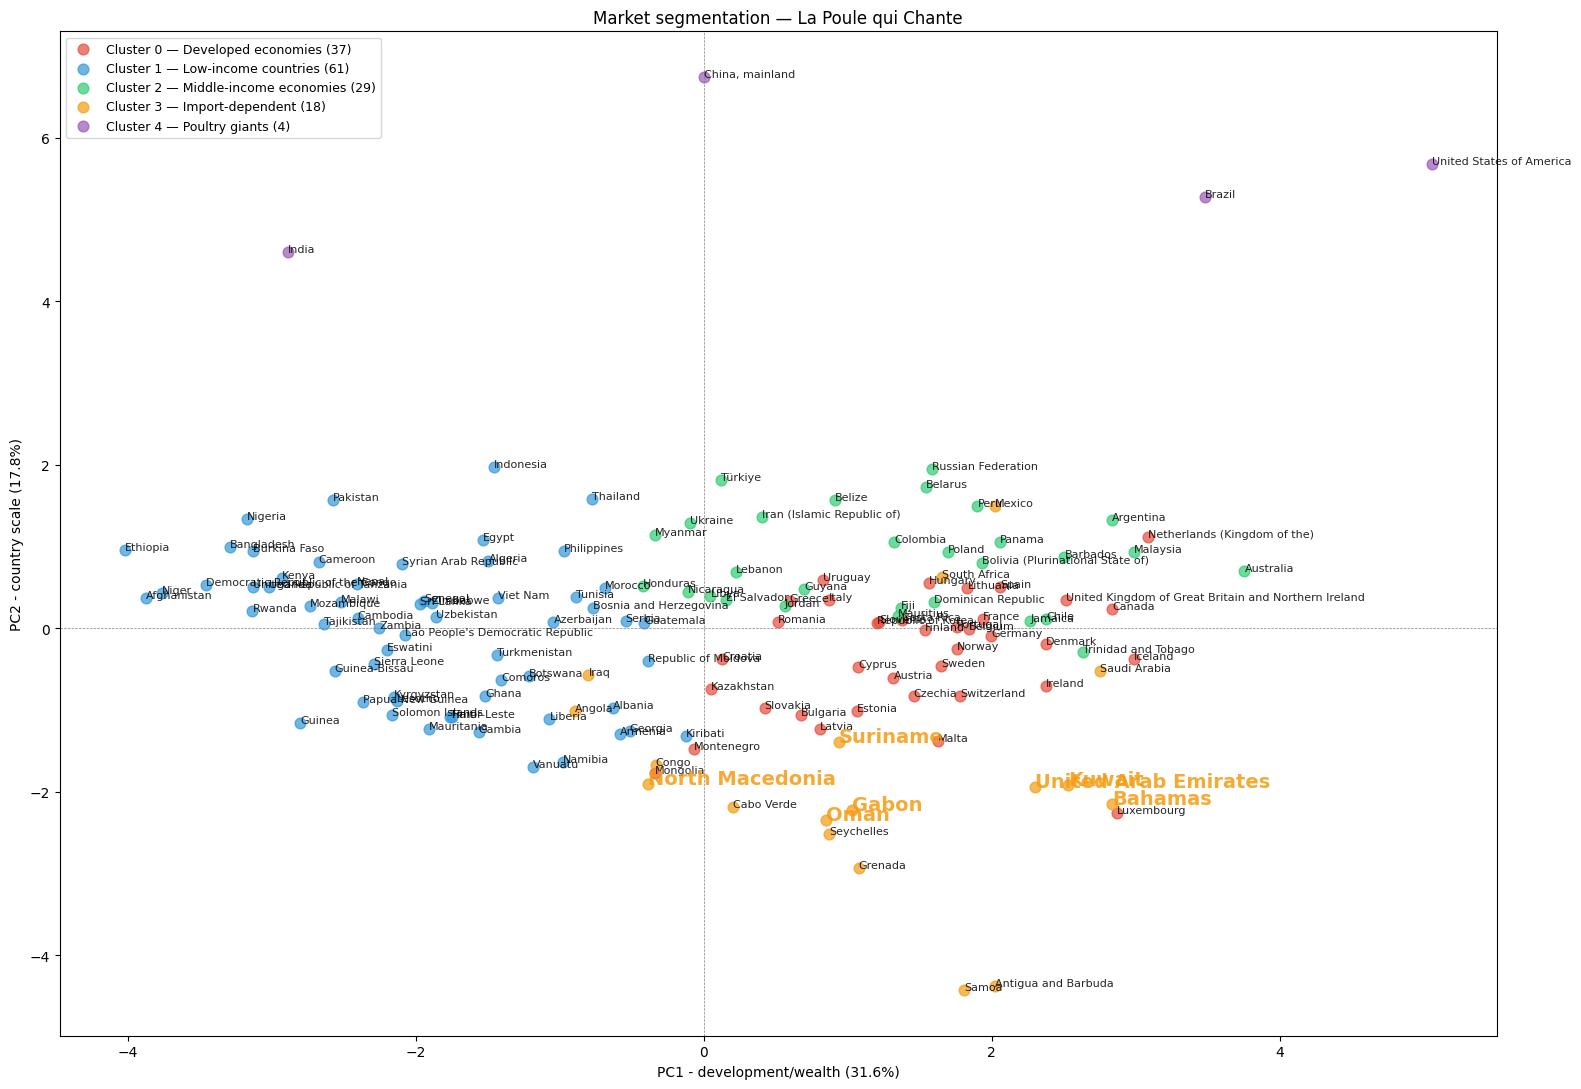

In [111]:
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

fig, ax = plt.subplots(figsize=(16, 11))

for cluster in range(5):
    mask = df_coords['cluster'] == cluster
    ax.scatter(
        df_coords.loc[mask, 'PC1'],
        df_coords.loc[mask, 'PC2'],
        c=colors[cluster],
        label=f'Cluster {cluster} — {cluster_names[cluster]} ({mask.sum()})',
        alpha=0.7,
        s=60
    )

for country in df_coords.index:
    fontsize = 14 if country in priority_country else 8
    weight = 'bold' if country in priority_country else 'normal'
    color = '#F39C12' if country in priority_country else 'black'
    # highlighted countries get bigger, bolder, purple labels
    
    ax.annotate(
        country,
        xy=(df_coords.loc[country, 'PC1'],
            df_coords.loc[country, 'PC2']),
        fontsize=fontsize,
        fontweight=weight,
        color=color,
        alpha=0.85
    )

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 - development/wealth ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 - country scale ({explained[1]:.1f}%)')
ax.set_title('Market segmentation — La Poule qui Chante')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

#### Graph 3D

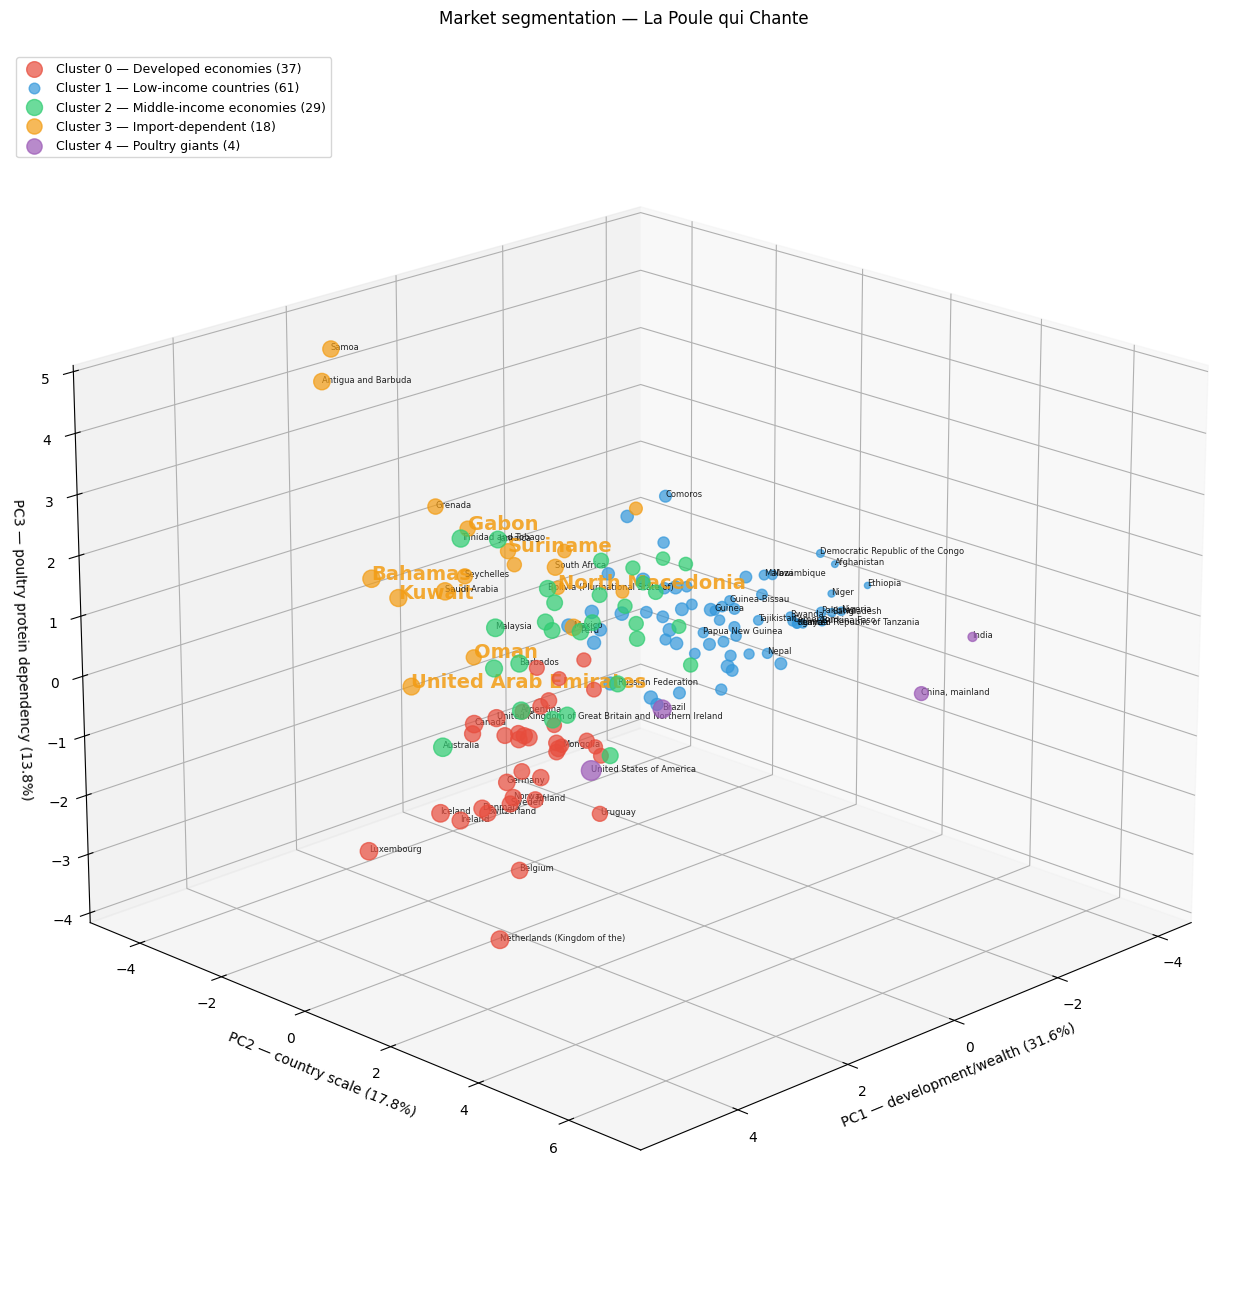

In [112]:
df_coords['distance_3d'] = np.sqrt(
    df_coords['PC1']**2 + 
    df_coords['PC2']**2 + 
    df_coords['PC3']**2
)

threshold = df_coords['distance_3d'].quantile(0.60)

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

depth = df_coords['PC1']
s_min, s_max = 20, 200
s_scaled = s_min + (s_max - s_min) * (
    (depth - depth.min()) / (depth.max() - depth.min())
)

fig = plt.figure(figsize=(18, 13))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(5):
    mask = df_coords['cluster'] == cluster
    ax.scatter(
        df_coords.loc[mask, 'PC1'],
        df_coords.loc[mask, 'PC2'],
        df_coords.loc[mask, 'PC3'],
        c=colors[cluster],
        label=f'Cluster {cluster} — {cluster_names[cluster]} ({mask.sum()})',
        alpha=0.7,
        s=s_scaled[mask]
    )

for country in df_coords.index:
    # On labellise toujours les pays prioritaires, sinon seulement si assez éloignés
    if country not in priority_country and df_coords.loc[country, 'distance_3d'] < threshold:
        continue

    fontsize = 14 if country in priority_country else 6
    weight = 'bold' if country in priority_country else 'normal'
    color = '#F39C12' if country in priority_country else 'black'

    ax.text(
        df_coords.loc[country, 'PC1'],
        df_coords.loc[country, 'PC2'],
        df_coords.loc[country, 'PC3'],
        country,
        fontsize=fontsize,
        fontweight=weight,
        color=color,
        alpha=0.85
    )

ax.set_xlabel(f'PC1 — development/wealth ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 — country scale ({explained[1]:.1f}%)')
ax.set_zlabel(f'PC3 — poultry protein dependency ({explained[2]:.1f}%)')
ax.set_title('Market segmentation — La Poule qui Chante', pad=20)
ax.legend(loc='upper left', fontsize=9)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

#### Interactive graph 3D

In [116]:
grapg_3d = df_coords.reset_index()
colors = {
    0: '#E74C3C',  
    1: '#3498DB',  
    2: '#2ECC71',  
    3: '#F39C12',  
    4: '#9B59B6',  
}

fig = px.scatter_3d(
    grapg_3d,
    x='PC1', y='PC2', z='PC3',
    color='cluster',
    color_discrete_map=colors,
    title='Market segmentation 3D',
    hover_name='country',
    labels={
        'PC1': f'PC1 wealth ({explained[0]:.1f}%)',
        'PC2': f'PC2 scale ({explained[1]:.1f}%)',
        'PC3': f'PC3 protein ({explained[2]:.1f}%)',
        'cluster': 'Cluster'
    }
)
fig.update_traces(marker=dict(size=5), textfont=dict(size=8))
fig.show()

### World map

In [114]:
import folium

cluster_df = df[['cluster']].reset_index()

colors = {
    0: '#E74C3C',  
    1: '#3498DB',  
    2: '#2ECC71',  
    3: '#F39C12',  
    4: '#9B59B6',  
}

name_fixes = {
    'China, mainland':                    'China',
    'Iran (Islamic Republic of)':         'Iran',
    'Türkiye':                            'Turkey',
    'Republic of Korea':                  'Korea',
    'Democratic Republic of the Congo':   'Democratic Republic of the Congo',
    'United Republic of Tanzania':        'Tanzania',
    'Bolivia (Plurinational State of)':   'Bolivia',
    'Viet Nam':                           'Vietnam',
    'Syrian Arab Republic':               'Syria',
    'Lao People\'s Democratic Republic':  'Laos PDR',
    'Netherlands (Kingdom of the)':       'Netherlands',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'China, mainland':                    'China',
    'United States of America':           'United States',
    'Democratic Republic of the Congo':   'Dem. Rep. Congo',
    'Czechia':                            'Czech Rep.',
    'Bosnia and Herzegovina':             'Bosnia and Herz.',
    'North Macedonia':                    'Macedonia',
    'Republic of Moldova':                'Moldova',
    'Russian Federation':                 'Russia'
}
# maps FAO country names → GeoJSON country names

cluster_df['country_geojson'] = cluster_df['country'].replace(name_fixes)

color_lookup = dict(zip(
    cluster_df['country_geojson'], 
    cluster_df['cluster'].map(colors)
))

name_lookup = dict(zip(
    cluster_df['country_geojson'],
    cluster_df['cluster'].map(cluster_names)
))

political_countries_url = (
    "http://geojson.xyz/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson"
)

m = folium.Map(location=(20, 10), zoom_start=2)
# zoom_start=2 shows the whole world

folium.GeoJson(
    political_countries_url,
    
    style_function=lambda feature: {
        'fillColor': color_lookup.get(
            feature['properties']['name'], '#cccccc'
        ),
        
        'color': 'white',      
        'weight': 0.5,         
        'fillOpacity': 0.7, 
    },
    
    tooltip=folium.GeoJsonTooltip(
        fields=['name'],
        aliases=['Country:'],
    )
).add_to(m)

# add legend
legend_html = """
<div style="position: fixed; top: 30px; right: 30px; z-index: 1000;
            background: white; padding: 12px; border-radius: 8px;
            border: 1px solid #ccc; font-size: 13px">
  <b>Clusters : La Poule qui Chante</b><br><br>
  <i style="background:#E74C3C;width:12px;height:12px;
     display:inline-block;margin-right:6px"></i>Developed economies<br>
  <i style="background:#3498DB;width:12px;height:12px;
     display:inline-block;margin-right:6px"></i>Low-income countries<br>
  <i style="background:#2ECC71;width:12px;height:12px;
     display:inline-block;margin-right:6px"></i>Middle-income economies<br>
  <i style="background:#F39C12;width:12px;height:12px;
     display:inline-block;margin-right:6px"></i>Import-dependent<br>
  <i style="background:#9B59B6;width:12px;height:12px;
     display:inline-block;margin-right:6px"></i>Poultry giants<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save("map.html")